In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('hotel_bookings.csv')

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df['children'] = df['children'].fillna(df['children'].mode()[0])
df['country'] = df['country'].fillna(df['country'].mode()[0])
df = df.drop(columns=['company', 'agent'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            8739

In [ ]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,0,No Deposit,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,0,No Deposit,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,0,No Deposit,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,0,No Deposit,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
sns.set_style('whitegrid')

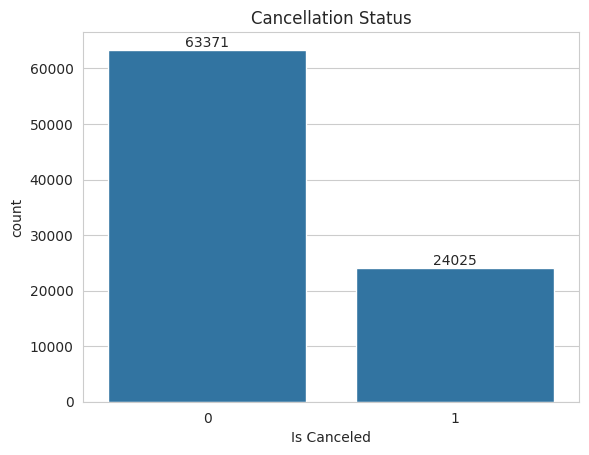

In [ ]:
P1=sns.countplot(data=df, x='is_canceled')
P1.bar_label(P1.containers[0])
plt.title("Cancellation Status")
plt.xlabel('Is Canceled')
plt.show()

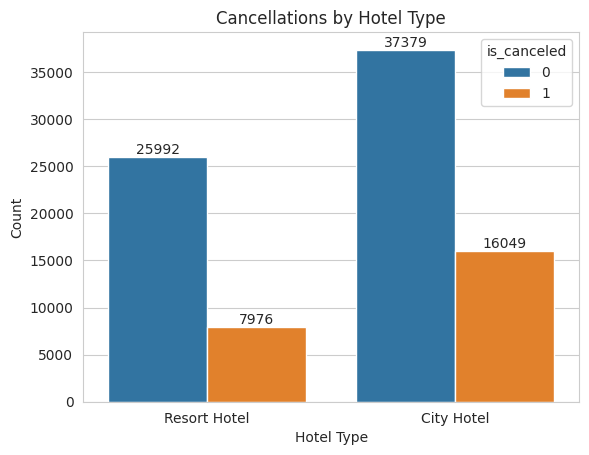

In [ ]:
P2=sns.countplot(data=df, x='hotel', hue='is_canceled')
P2.bar_label(P2.containers[0])
P2.bar_label(P2.containers[1])
plt.title("Cancellations by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()

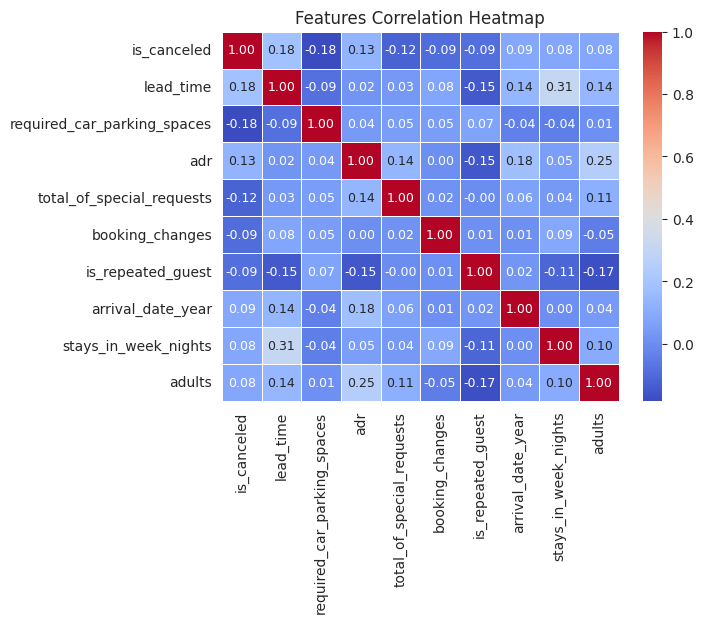

In [ ]:
corr = df.corr(numeric_only=True)
top_corr_features = corr['is_canceled'].abs().sort_values(ascending=False).index[:10]
top_corr_matrix = df[top_corr_features].corr(numeric_only=True)
plt.figure()
sns.heatmap(
    top_corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Correlation Heatmap')
plt.show()

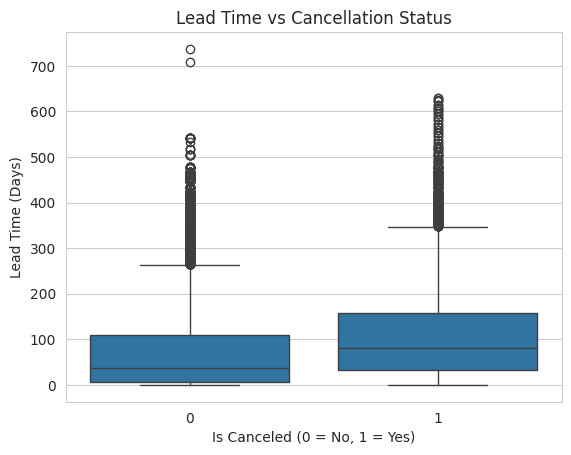

In [ ]:
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title('Lead Time vs Cancellation Status')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (Days)')
plt.show()

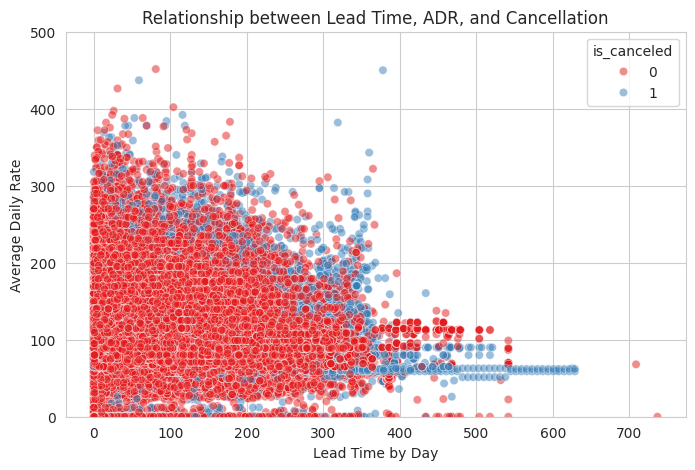

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='lead_time', y='adr', hue='is_canceled', alpha=0.5, palette='Set1')

plt.title('Relationship between Lead Time, ADR, and Cancellation')
plt.xlabel('Lead Time by Day')
plt.ylabel('Average Daily Rate')
plt.ylim(0, 500)
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [25]:
features = ['lead_time', 'total_of_special_requests', 'required_car_parking_spaces', 'adr', 'booking_changes']
X = df[features]
y = df['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

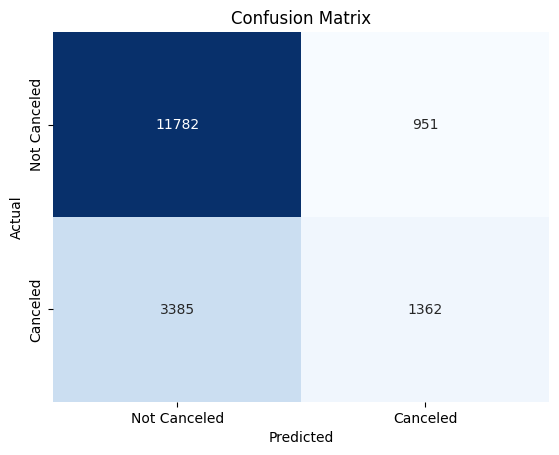

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(ticks=[0.5, 1.5], labels=['Not Canceled', 'Canceled'])
plt.yticks(ticks=[0.5, 1.5], labels=['Not Canceled', 'Canceled'])
plt.show()

Logistic Regression:
Cross Val Score: 0.74
F1 Score: 0.70
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.95      0.85     12733
           1       0.61      0.19      0.29      4747

    accuracy                           0.75     17480
   macro avg       0.68      0.57      0.57     17480
weighted avg       0.72      0.75      0.70     17480



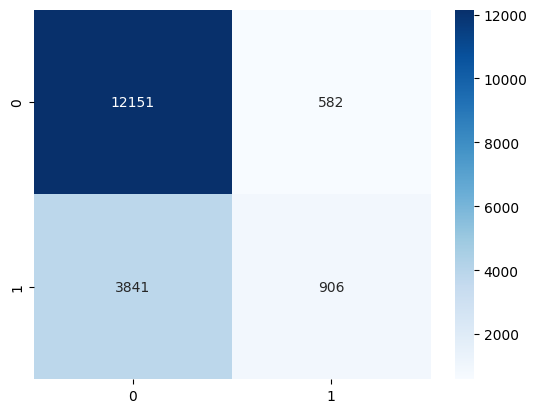

---------------------------------------------------
K-Nearest Neighbors:
Cross Val Score: 0.70
F1 Score: 0.70
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81     12733
           1       0.45      0.35      0.40      4747

    accuracy                           0.71     17480
   macro avg       0.62      0.60      0.60     17480
weighted avg       0.69      0.71      0.70     17480



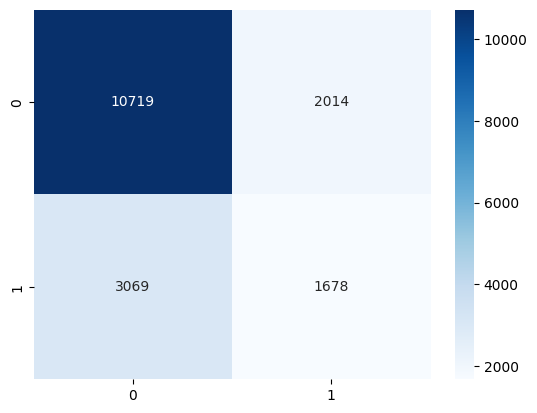

---------------------------------------------------
Support Vector Machine:
Cross Val Score: 0.73
F1 Score: 0.62
Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84     12733
           1       0.59      0.01      0.02      4747

    accuracy                           0.73     17480
   macro avg       0.66      0.50      0.43     17480
weighted avg       0.69      0.73      0.62     17480



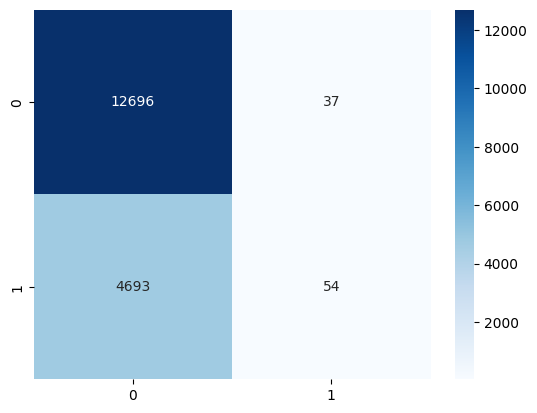

---------------------------------------------------
Decision Tree:
Cross Val Score: 0.71
F1 Score: 0.71
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     12733
           1       0.46      0.43      0.45      4747

    accuracy                           0.71     17480
   macro avg       0.63      0.62      0.62     17480
weighted avg       0.70      0.71      0.71     17480



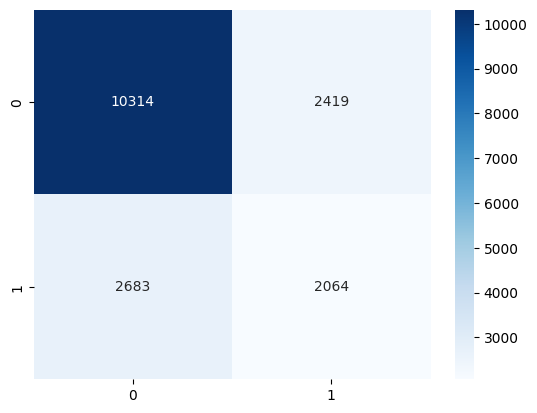

---------------------------------------------------
Random Forest:
Cross Val Score: 0.73
F1 Score: 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82     12733
           1       0.51      0.42      0.46      4747

    accuracy                           0.73     17480
   macro avg       0.65      0.63      0.64     17480
weighted avg       0.72      0.73      0.72     17480



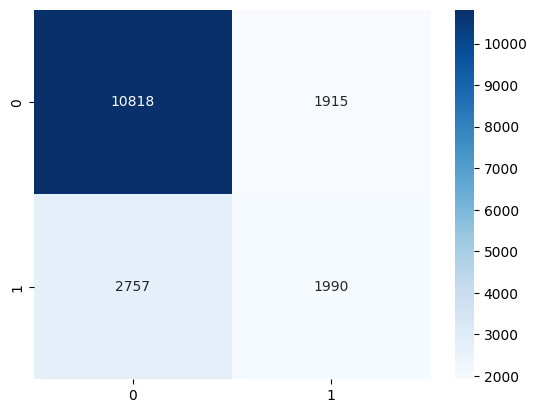

---------------------------------------------------
Gradient Boosting:
Cross Val Score: 0.76
F1 Score: 0.73
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85     12733
           1       0.61      0.31      0.41      4747

    accuracy                           0.76     17480
   macro avg       0.69      0.62      0.63     17480
weighted avg       0.73      0.76      0.73     17480



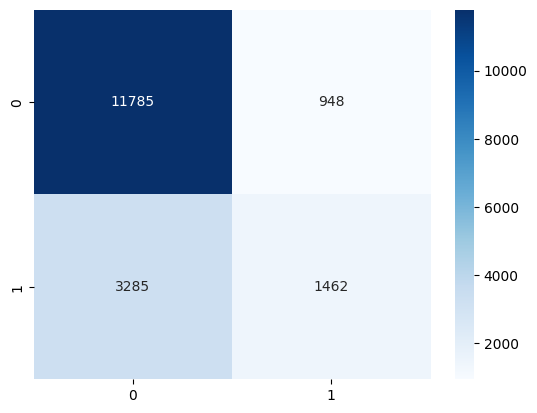

---------------------------------------------------
xgboost:
Cross Val Score: 0.76
F1 Score: 0.74
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85     12733
           1       0.61      0.36      0.46      4747

    accuracy                           0.76     17480
   macro avg       0.70      0.64      0.65     17480
weighted avg       0.74      0.76      0.74     17480



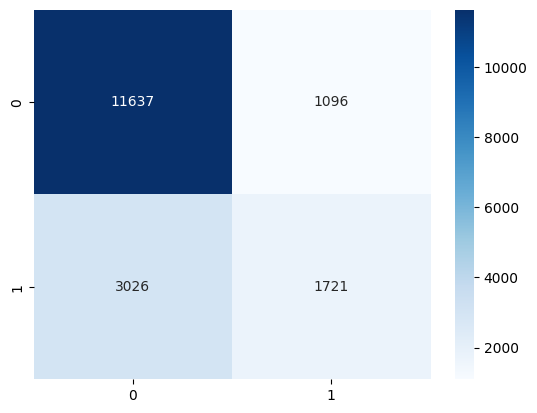

---------------------------------------------------


In [17]:
from sklearn.metrics import classification_report , f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb


classifiers = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Support Vector Machine', SVC(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('xgboost', xgb.XGBClassifier(tree_method="hist")),
]


for clf_name, clf in classifiers:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    print(f'{clf_name}:')
    print(f"Cross Val Score: {cv_scores.mean():.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')
    plt.show()
    print('---------------------------------------------------')

In [20]:
from sklearn.preprocessing import LabelEncoder
df = df.drop(columns=['reservation_status', 'reservation_status_date'], errors='ignore')

In [21]:
df_label = df.copy()
categorical_cols = df_label.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col])
    label_encoders[col] = le

In [22]:
target_col = 'is_canceled'

X = df_label.drop(columns=[target_col])
y = df_label[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=150,
                       n_jobs=-1, random_state=42)

=== Final Model Performance ===
Weighted F1-Score: 0.8089

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.80      0.85     12675
           1       0.60      0.81      0.69      4805

    accuracy                           0.80     17480
   macro avg       0.76      0.80      0.77     17480
weighted avg       0.83      0.80      0.81     17480



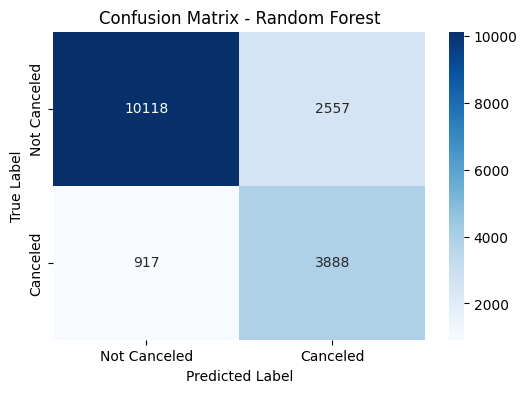

In [ ]:
y_pred = model.predict(X_test)

print("=== Final Model Performance ===")
print("Weighted F1-Score:", round(f1_score(y_test, y_pred, average='weighted'), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

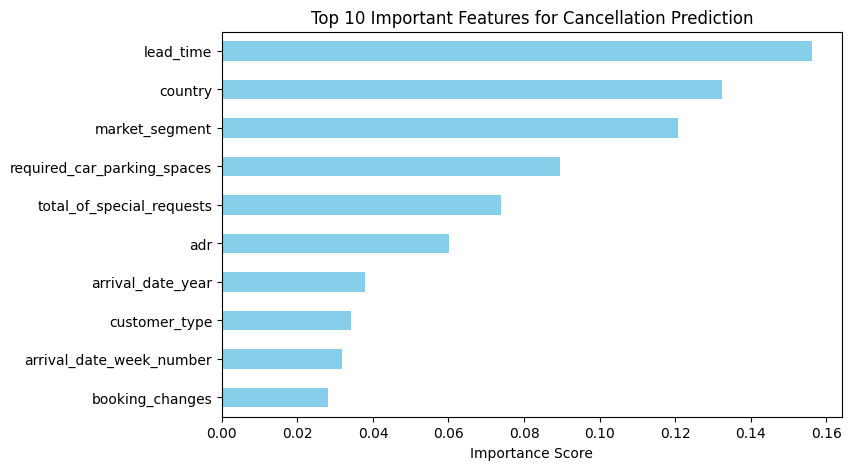

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features for Cancellation Prediction")
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)

print(f'Training Error: {train_error:.4f}')
print(f'Test Error: {test_error:.4f}')

Training Error: 0.2596
Test Error: 0.2592


In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

rmse = np.sqrt(test_error)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2 Score: {r2:.4f}')

RMSE: 0.5091
MAE: 0.2592
R2 Score: -0.1051


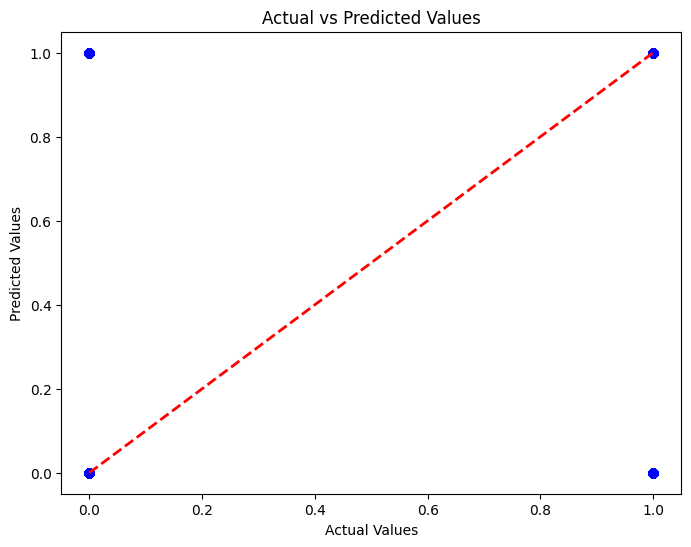

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, color='blue')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

In [35]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("Cross-Validation MSE scores:", -cv_scores)
print("Average CV MSE:", -cv_scores.mean())

Cross-Validation MSE scores: [0.26221012 0.26310004 0.25981573 0.25850696 0.26855827]
Average CV MSE: 0.2624382231163155


In [37]:
import joblib
joblib.dump(model, 'hotel_model.pkl')
joblib.dump(label_encoders, 'encoders.pkl')
print("\nModel and Encoders successfully saved to disk.")


Model and Encoders successfully saved to disk.
